In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# from analysis import craftax_model_data
import ipywidgets
from tqdm.notebook import tqdm
from IPython.display import display

from analysis import craftax_user_data
from analysis import craftax_analysis
from analysis import experiment_analysis
import nicewebrl
import matplotlib.pyplot as plt
import polars as pl


%matplotlib inline

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/craftax/craftax/assets/fullmap_texture_cache_48.pbz2
Textures successfully loaded from cache.
Compiling environment reset and step functions.
	reset time: 11.384468078613281
	step time: 14.112996816635132
Compiling multi-render function.
	time: 3.4733638763427734


A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

A* Iterations: 0it [00:00, ?it/s]

In [4]:
# # ON SERVER
# RESULTS_DIR = "/n/holylfs06/LABS/kempner_fellow_wcarvalho"
# USER_RESULTS_DIR = os.path.join(
#   RESULTS_DIR, "results/human_dyna_craftax/user_data/exps"
# )

In [5]:
# ON COMPUTER
RESULTS_DIR = "/Users/wilka/git/research/"
DATA_DIR = os.path.join(RESULTS_DIR, "results/human_dyna_craftax")
USER_RESULTS_DIR = os.path.join(DATA_DIR, "user_data/exps")

In [6]:
from glob import glob

files = f"{USER_RESULTS_DIR}/*v3*.json"

files = list(set(glob(files)))
files[:5]

['/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=213640548_worker=A2FHM2F9QKP0O0_name=craftax_v3-paths-r1-m0_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2998019967_worker=A3QNCW3LR2AVOV_name=craftax_v3-paths-r0-m0_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=4145025209_worker=A3BSK47WPPE876_name=craftax_v3-paths-r0-m0_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=10434196_worker=A2EH7IQCDH2Q5D_name=craftax_v3-paths-r0-m0_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=122928105_worker=A3N770LD28YDL1_name=craftax_v3-paths-r0-m0_debug=0.json']

In [7]:
import craftax_experiment_structure as experiment
import asyncio

# %debug
user_df = await craftax_user_data.get_human_data(
  files,
  overwrite_episode_data=False,
  overwrite_episode_info=False,
  debug=False,
)

Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0_episode_info.csv
0/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0.json
Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2679367757_worker=A3V9JFVZQ2XF4Y_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2679367757_worker=A3V9JFVZQ2XF4Y_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
1/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2679367757_worker=A3V9JFVZQ2X

Failed to unpack record in /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_debug=0.json: unpack(b) received extra data.


Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2009763096_worker=A2ZYZ05XQ6TLOT_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2009763096_worker=A2ZYZ05XQ6TLOT_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
4/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2009763096_worker=A2ZYZ05XQ6TLOT_name=craftax_v3-paths-r1-m0_debug=0.json
Skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_debug=0.json because it is not finished
5/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_debug=0.json
skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=311884650_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r1-m0_d

Failed to unpack record in /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json: unpack(b) received extra data.


Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3651975810_worker=ABBZGF22NICO7_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3651975810_worker=ABBZGF22NICO7_name=craftax_v3-paths-r0-m0_debug=0_episode_info.csv
7/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=3651975810_worker=ABBZGF22NICO7_name=craftax_v3-paths-r0-m0_debug=0.json
Skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json because it is not finished
8/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1641903520_worker=A3BUPP17GN7I1H_name=craftax_v3-paths-r0-m0_d

...

Skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2343945951_worker=A3KXCBNBQAU992_name=craftax_v3-paths-r1-m0_debug=0.json because it is not finished
18/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2343945951_worker=A3KXCBNBQAU992_name=craftax_v3-paths-r1-m0_debug=0.json
skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2343945951_worker=A3KXCBNBQAU992_name=craftax_v3-paths-r1-m0_debug=0.json because one of the episode_df or episode_data is None
Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3602276455_worker=A13I8ASC3JQ04P_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=3602276455_worker=A13I8ASC3JQ04P_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
19/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=360

Failed to unpack record in /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1207509733_worker=A1F6MWP9A0XLJQ_name=craftax_v3-paths-r1-m0_debug=0.json: unpack(b) received extra data.


Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=1575818269_worker=A25BFYCETHHKN3_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=1575818269_worker=A25BFYCETHHKN3_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
20/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1575818269_worker=A25BFYCETHHKN3_name=craftax_v3-paths-r1-m0_debug=0.json
21/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2998019967_worker=A3QNCW3LR2AVOV_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2998019967_worker=A3QNCW3LR2AVOV_name=craftax_v3-paths-r0-m0_debug=0.json because one of the episode_df or episode_data is None
Skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=1207509733_worker=A1F6MWP9A0XL

Failed to unpack record in /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json: unpack(b) received extra data.


Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2933138588_worker=AU849EHZNGV2Z_name=craftax_v3-paths-r1-m0_debug=0_episode_data.bytes
Loaded episode info from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2933138588_worker=AU849EHZNGV2Z_name=craftax_v3-paths-r1-m0_debug=0_episode_info.csv
24/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2933138588_worker=AU849EHZNGV2Z_name=craftax_v3-paths-r1-m0_debug=0.json
Skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json because it is not finished
25/43 /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug=0.json
skipping /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=957564031_worker=AJQ71YIGY01HZ_name=craftax_v3-paths-r0-m0_debug

In [7]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
from analysis import craftax_download_data
from analysis import craftax_model_data
################
# Load model data
################
model_df = craftax_model_data.get_model_data(
  qlearning_path=f"{craftax_download_data.qlearning_local_dir}/seed=*",
  sf_path=f"{craftax_download_data.sf_local_dir}/seed=*",
  preplay_path=f"{craftax_download_data.preplay_local_dir}/seed=*",
  # search_path=f"{data_dir}/search_algos",
  cache_dir='craftax_cache/model_data_cache',
  overwrite_episodes=False,
  overwrite_df=False,
)

Loaded cached model data from craftax_cache/model_data_cache/model_data_cache_episodes.pickle


# Get files

# Model

In [14]:
import craftax_utils

df = model_df.filter(algo='preplay', eval=True, success=0)
craftax_utils.create_episode_video(df.episodes[0], fps=3)
df.head()

index,eval,global_episode_idx,name,algo,world_seed,start_pos,task,placed_goals,placed_achievements,room,maze,total_reward,success,path_length,task_vector,seed,reuse,overlap
u32,bool,i64,str,str,i64,str,i64,str,str,i64,i64,f64,f64,i64,str,i64,i64,f64
0,true,4,"""paths_0_eval1""","""preplay""",3,"""[28 25]""",19,"""[21 22 10]""","""[54 59 19]""",0,3,0.0,0.0,100,"""[1. 0. 0.]""",6,null,null
1,true,5,"""paths_1_eval1""","""preplay""",15,"""[24 24]""",54,"""[22 10 21]""","""[59 19 54]""",0,15,0.0,0.0,100,"""[0. 1. 0.]""",6,null,null
2,true,6,"""paths_2_eval1""","""preplay""",20,"""[18 30]""",59,"""[10 21 22]""","""[19 54 59]""",0,20,0.0,0.0,100,"""[0. 0. 1.]""",6,null,null
3,true,7,"""paths_3_eval1""","""preplay""",95,"""[ 7 16]""",19,"""[21 22 10]""","""[54 59 19]""",0,95,0.0,0.0,100,"""[1. 0. 0.]""",6,null,null
4,true,5,"""paths_1_eval1""","""preplay""",15,"""[24 24]""",54,"""[22 10 21]""","""[59 19 54]""",0,15,0.0,0.0,100,"""[0. 1. 0.]""",10,0,0.078947


In [13]:
import jax

# jax.tree_map(lambda x:x.shape, df.episodes[1]timesteps.rewards)
df.episodes[1].timesteps.reward

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)

In [9]:
import craftax_utils

df = model_df.filter(algo='usfa', eval=True, reuse=0)
craftax_utils.create_episode_video(df.episodes[1], fps=3)
df.head()

index,eval,global_episode_idx,name,algo,world_seed,start_pos,task,placed_goals,placed_achievements,room,maze,total_reward,success,path_length,task_vector,seed,reuse,overlap
u32,bool,i64,str,str,i64,str,i64,str,str,i64,i64,f64,f64,i64,str,i64,i64,f64
0,true,4,"""paths_0_eval1""","""usfa""",3,"""[28 25]""",19,"""[21 22 10]""","""[54 59 19]""",0,3,0.0,0.0,100,"""[1. 0. 0.]""",1,0,0.058824
1,true,6,"""paths_2_eval1""","""usfa""",20,"""[18 30]""",59,"""[10 21 22]""","""[19 54 59]""",0,20,0.0,0.0,100,"""[0. 0. 1.]""",1,0,0.029412
2,true,7,"""paths_3_eval1""","""usfa""",95,"""[ 7 16]""",19,"""[21 22 10]""","""[54 59 19]""",0,95,0.0,0.0,100,"""[1. 0. 0.]""",1,0,0.035714
3,true,5,"""paths_1_eval1""","""usfa""",15,"""[24 24]""",54,"""[22 10 21]""","""[59 19 54]""",0,15,0.0,0.0,100,"""[0. 1. 0.]""",2,0,0.027778
4,true,6,"""paths_2_eval1""","""usfa""",20,"""[18 30]""",59,"""[10 21 22]""","""[19 54 59]""",0,20,0.0,0.0,100,"""[0. 0. 1.]""",2,0,0.029412


In [10]:
import craftax_utils

df = model_df.filter(algo='preplay', eval=False, world_seed=95, start_pos="[ 7 16]")
craftax_utils.create_episode_video(df.episodes[0], fps=3)
df.head()

index,eval,global_episode_idx,name,algo,world_seed,start_pos,task,placed_goals,placed_achievements,room,maze,total_reward,success,path_length,task_vector,seed,reuse,overlap
u32,bool,i64,str,str,i64,str,i64,str,str,i64,i64,f64,f64,i64,str,i64,i64,f64
0,false,3,"""paths_3_training""","""preplay""",95,"""[ 7 16]""",54,"""[21 22 10]""","""[54 59 19]""",0,95,1.0,1.0,29,"""[0. 1. 0.]""",1,null,null


In [14]:
df = model_df.filter(algo='preplay', eval=True, world_seed=95)
craftax_utils.create_episode_video(df.episodes[0], fps=3)
df.head()

index,eval,global_episode_idx,name,algo,world_seed,start_pos,task,placed_goals,placed_achievements,room,maze,total_reward,success,path_length,task_vector,seed,reuse,overlap
u32,bool,i64,str,str,i64,str,i64,str,str,i64,i64,f64,f64,i64,str,i64,i64,f64
0,true,7,"""paths_3_eval1""","""preplay""",95,"""[ 7 16]""",19,"""[21 22 10]""","""[54 59 19]""",0,95,1.0,1.0,28,"""[1. 0. 0.]""",1,0,0.035714


In [11]:
craftax_utils.create_episode_video(
    model_df.filter(algo='preplay', eval=False, maze=3, start_pos="[32 30]").episodes[0],
    fps=3,
)

IndexError: list index out of range

# User

In [50]:

craftax_utils.create_episode_video(
    user_df.filter(eval=True, reuse=True, success=1, tell_reuse=0).episodes[7],
    fps=3,
)

In [59]:
df.filter(eval=True, reuse=False)["start_pos"]

start_pos
str
"""[18 30]"""


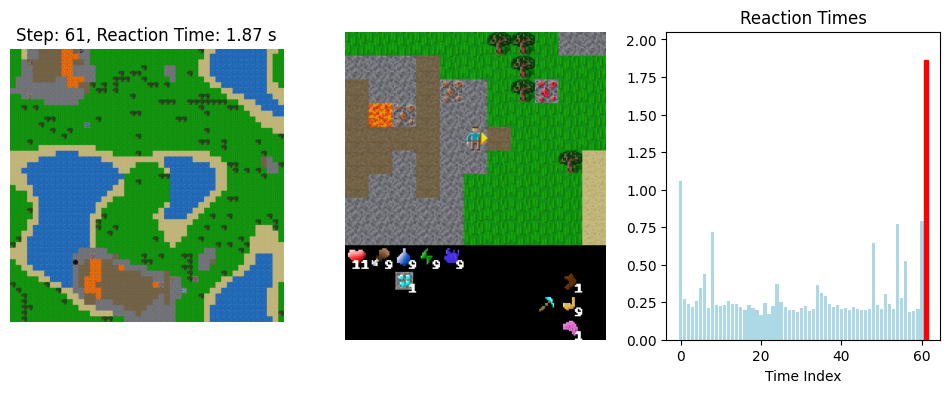

In [60]:
craftax_utils.create_episode_reaction_times_video(
  df.filter(eval=False, start_pos="[18 30]").episodes[0]
)

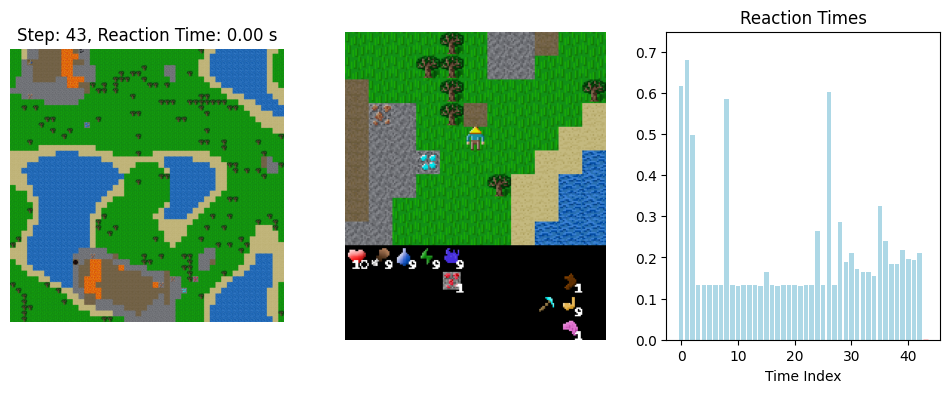

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(
  df.filter(eval=True, reuse=False).episodes[0]
)

In [33]:
all_mazes = df["name"].unique()
train_mazes = sorted([m for m in all_mazes if "training" in m])
test_mazes = sorted([m for m in all_mazes if "eval" in m])

# for i in range(len(train_mazes)):
name = test_mazes[0]
name = "paths_3_eval1"
test = df.filter(name=name, eval=True)
start_pos = test["start_pos"].to_list()[0]

name = "paths_3_training"
train = df.filter(name=name, room=0, eval=False, start_pos=start_pos)
print(len(train.episodes))
test.head()

1


index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,bool,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,i32,f64
0,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",36,1,true,10,0,"""[ 7 16]""",2951292398,36,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,28,false,1.0,35,1.0,-0.100915,-1.471479,-51.501762,-1.51179,-0.100915,-0.454115,-0.454115,-0.689135,-0.689135,7,1,0.366667


In [35]:
train = df.filter(name=name, eval=False, start_pos=start_pos)
train.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,i64,bool,f64
0,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",0,1,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,32,1.0,0.36326,31,null,null
1,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",9,10,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,16,1.0,1.911911,15,null,null
2,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",11,12,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,14,1.0,1.250191,13,null,null


In [68]:
df_added = craftax_user_data.add_reuse_columns(df, overlap_threshold=0.15)

In [69]:
not_reuse = df_added.filter(reuse=False)
not_reuse.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64


In [70]:
reused = df_added.filter(reuse=True)
reused.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64
0,15,1,"""paths_1_eval1""","""reusing longer of two paths wh…","""paths""",17,1,true,21,0,"""[24 24]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,53,1.0,0.708533,-1.23248,-65.321426,-1.269807,0.708533,-0.006008,-0.006008,-0.970193,-0.648155,52,true,0.244898
1,20,1,"""paths_2_eval1""","""reusing longer of two paths wh…","""paths""",34,1,true,22,0,"""[18 30]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,45,1.0,0.359079,-1.486778,-66.905022,-1.52873,0.359079,-0.49921,-0.49921,-0.731867,-0.731867,44,true,0.622222
2,3,1,"""paths_0_eval1""","""reusing longer of two paths wh…","""paths""",51,1,true,10,0,"""[28 25]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,38,1.0,0.05355,-1.516469,-57.625835,-1.558902,0.05355,-0.848609,-0.848609,-0.928844,-0.928844,37,true,0.529412
3,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",68,1,true,10,0,"""[ 7 16]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,42,1.0,-1.093595,-1.606121,-67.4571,-1.618622,-0.918769,-0.918769,-1.15833,-0.918769,-0.918769,41,true,0.342105


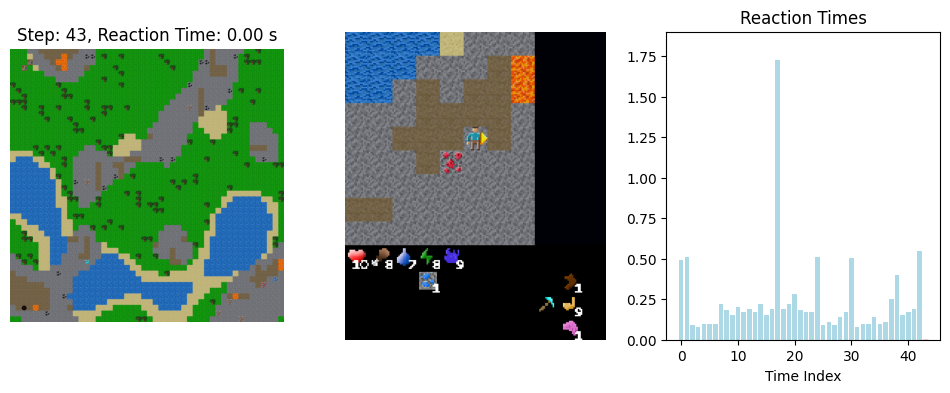

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(reused.episodes[0])

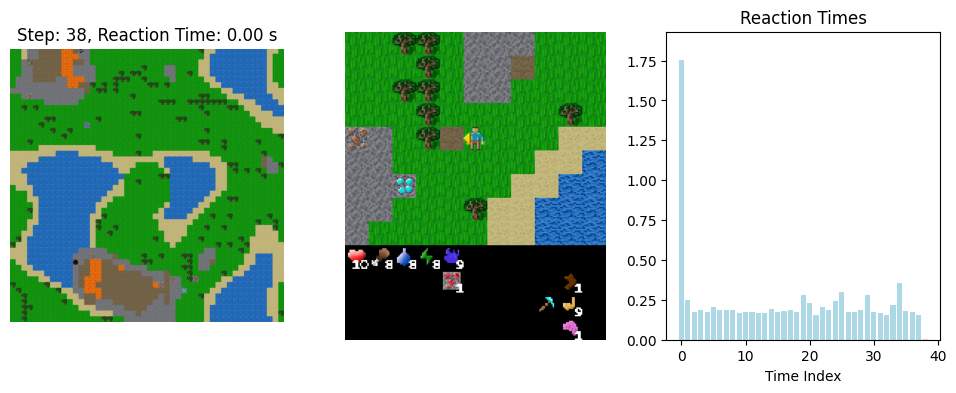

In [59]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[0])

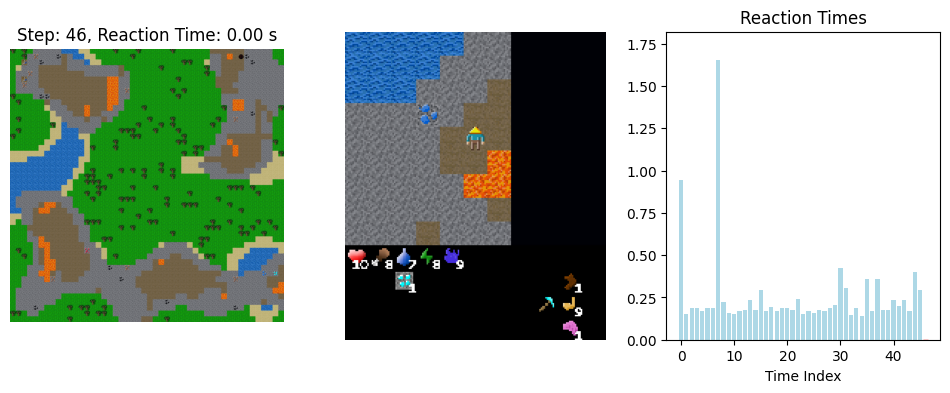

In [60]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[1])